In [29]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [30]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
import zipfile

zip_path = "/content/drive/MyDrive/AI/workshop5/FruitinAmazon.zip"
extract_path = "/content/FruitinAmazon"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted!")

Dataset extracted!


In [32]:
import os
print(os.listdir("/content/FruitinAmazon"))

['FruitinAmazon']


In [33]:
print(os.listdir("/content/FruitinAmazon"))

['FruitinAmazon']


In [34]:
image_size = (128, 128)
batch_size = 32
train_dir = "/content/FruitinAmazon/FruitinAmazon/train"

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size
)

class_names = train_ds.class_names
print("Classes:", class_names)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.
Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


In [35]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.2),
])

In [36]:
model = keras.Sequential([
    layers.Input(shape=(128, 128, 3)),

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, 3, padding="same"),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),
    layers.Dropout(0.3),

    # Flatten + Dense
    layers.Flatten(),
    layers.Dense(256),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.Dropout(0.5),

    layers.Dense(len(class_names), activation="softmax")
])

In [37]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [38]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 13s 2s/step - accuracy: 0.2083 - loss: 2.6527 - val_accuracy: 0.0556 - val_loss: 1.9240
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.5417 - loss: 1.3136 - val_accuracy: 0.1111 - val_loss: 1.8041
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 2s/step - accuracy: 0.6528 - loss: 0.9668 - val_accuracy: 0.2778 - val_loss: 1.7728
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6806 - loss: 1.0276 - val_accuracy: 0.2222 - val_loss: 1.8247
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.6806 - loss: 0.7194 - val_accuracy: 0.2222 - val_loss: 1.9793
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7639 - loss: 0.6654 - val_accuracy: 0.2222 - val_loss: 2.1513
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.7639 - loss: 0.6690 - val_accuracy: 0.2222 - val_loss: 2.2808
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7639 - loss: 0.6355 - val_accuracy: 0.2222 - val_loss: 2.3429
Epoch 9/10
3/3

In [39]:
test_loss, test_acc = model.evaluate(val_ds)
print("Test Accuracy:", test_acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - accuracy: 0.2222 - loss: 2.4216
Test Accuracy: 0.2222222238779068


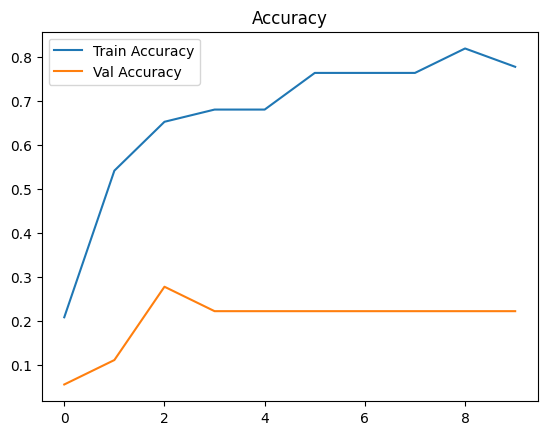

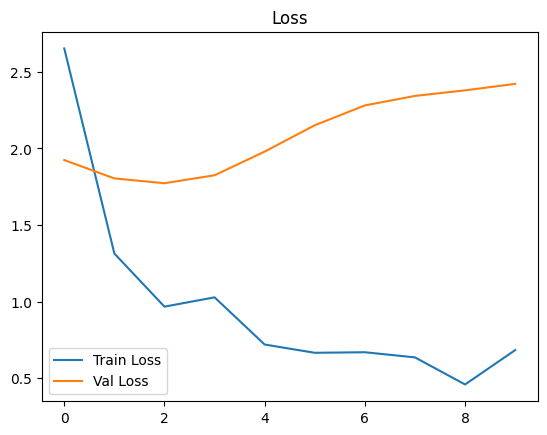

In [40]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [41]:
image_size = (224, 224)

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=32
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [42]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [43]:
for layer in base_model.layers:
    layer.trainable = False

In [44]:
from tensorflow.keras import Model

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(512, activation="relu")(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(len(train_ds.class_names), activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)

In [45]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [27]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.2222 - loss: 8.6000 - val_accuracy: 0.5000 - val_loss: 4.5480
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 51s 16s/step - accuracy: 0.4167 - loss: 3.4082 - val_accuracy: 0.5556 - val_loss: 3.5842
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 16s/step - accuracy: 0.6111 - loss: 1.7445 - val_accuracy: 0.5556 - val_loss: 3.1621
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 47s 15s/step - accuracy: 0.8472 - loss: 1.2237 - val_accuracy: 0.4444 - val_loss: 3.6629
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 16s/step - accuracy: 0.8889 - loss: 0.5481 - val_accuracy: 0.4444 - val_loss: 3.7185
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 50s 17s/step - accuracy: 0.8889 - loss: 0.4503 - val_accuracy: 0.5556 - val_loss: 3.6124
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 80s 15s/step - accuracy: 0.9583 - loss: 0.1797 - val_accuracy: 0.5556 - val_loss: 3.8196
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 15s/step - accuracy: 0.9583 - loss: 0.2038 - val_accuracy: 0.5556 - val_loss: 3.8712


In [28]:
model.evaluate(val_ds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.6111 - loss: 3.8600


[3.859987497329712, 0.6111111044883728]

In [46]:
from sklearn.metrics import classification_report
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         3
           1       1.00      0.25      0.40         4
           2       0.00      0.00      0.00         1
           3       0.25      1.00      0.40         1
           4       0.00      0.00      0.00         4
           5       0.14      0.20      0.17         5

    accuracy                           0.17        18
   macro avg       0.23      0.24      0.16        18
weighted avg       0.28      0.17      0.16        18

